# Cleaning a PostgreSQL Database
![Clean PostgreSQL Database](Project_Image.jpeg)

Work with superstore data in PostgreSQL, reformatting and analyzing to answer some day-to-day retail business questions, like what are the top performing products, and how missing data can be imputed for quantity of products per order.

In this project, you will work with data from a hypothetical Super Store to challenge and enhance your SQL skills in data cleaning. This project will engage you in identifying top categories based on the highest profit margins and detecting missing values, utilizing your comprehensive knowledge of SQL concepts.

## Data Dictionary:

### `orders`:
| Column | Definition | Data type | Comments |
|--------|------------|-----------|----------|
| `row_id`| Unique Record ID | `INTEGER` |
| `order_id` | Identifier for each order in table | `TEXT` | Connects to `order_id` in `returned_orders` table |
| `order_date` | Date when order was placed | `TEXT` |
| `market` | Market order_id belongs to | `TEXT` |
| `region` | Region Customer belongs to | `TEXT` | Connects to `region` in `people` table |
| `product_id` | Identifier of Product bought | `TEXT` | Connects to `product_id` in `products` table |
| `sales` | Total Sales Amount for the Line Item | `DOUBLE PRECISION` |
| `quantity` | Total Quantity for the Line Item | `DOUBLE PRECISION` |
| `discount` | Discount applied for the Line Item | `DOUBLE PRECISION` |
| `profit` | Total Profit earned on the Line Item | `DOUBLE PRECISION` |

### `returned_orders`:
| Column | Definition | Data type |
|--------|------------|-----------|
| `returned`| Yes values for Order / Line Item Returned | `TEXT` |
| `order_id` | Identifier for each order in table | `TEXT` |
| `market` | Market order_id belongs to | `TEXT` |

### `people`:
| Column | Definition | Data type |
|--------|------------|-----------|
| `person`| Name of Salesperson credited with Order | `TEXT` |
| `region` | Region Salesperson in operating in | `TEXT` |

### `products`:
| Column | Definition | Data type |
|--------|------------|-----------|
| `product_id`| Unique Identifier for the Product | `TEXT` |
| `category` | Category Product belongs to | `TEXT` |
| `sub_category` | Sub Category Product belongs to | `TEXT` |
| `product_name` | Detailed Name of the Product | `TEXT` |

As you can see in the Data Dictionary above, date fields have been written to the `orders` table as `TEXT` and numeric fields like sales, profit, etc. have been written to the `orders` table as `Double Precision`. You will need to take care of these types in some of the queries. This project is an excellent opportunity to apply your SQL skills in a practical setting and gain valuable experience in data cleaning and analysis. Good luck, and happy querying!

# Analysis I
Find the top 5 products from each category based on highest total sales. The output should be sorted by `category` in ascending order & by `sales` in descending order within each category, i.e. within each category product with highest margin should sit on the top. Save the query as `top_five_products_each_category`, containing the following columns:
- `category`,
- `product_name`,
- `product_total_sales` (rounded to 2 decimal places),
- `product_total_profit` (rounded to 2 decimal places),
- `product_rank`

In [ ]:
# Q1) - top_five_products_each_category
# There are 3 unique categories (Furniture, Office Supplies, Technology)
# To round to 2 decimals in PostgreSQL, need to convert the DOUBLE PRECISION values to NUMERICs

SELECT category, product_name, product_total_sales, product_total_profit, 
    product_rank
FROM (
    SELECT product_name, category, ROUND(SUM(sales)::NUMERIC, 2) AS product_total_sales, 
        ROUND(SUM(profit)::NUMERIC, 2) AS product_total_profit, 
        ROW_NUMBER() OVER(PARTITION BY category ORDER BY SUM(sales) DESC) AS product_rank
    FROM orders
    LEFT JOIN products
    USING(product_id)
    GROUP BY product_name, category
    ORDER BY category, product_total_sales DESC) AS subq
WHERE product_rank < 6;
    #produces 15 rows

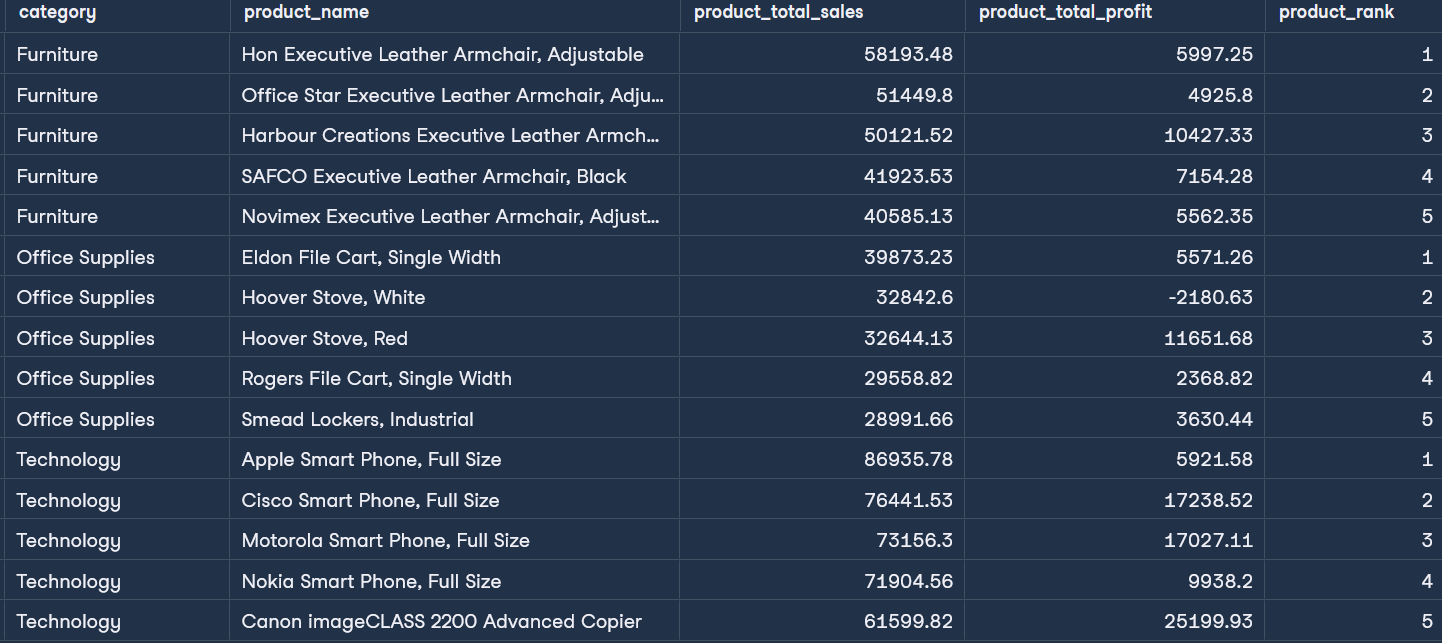

Based on these items, technology products were clearly the most expensive items that were sold, whereas items in the Office Supplies category were the cheapest. Furthermore, total profits are generally correlated with total sales across these products. Specifically, total profits were higher across the most sold technology items, whereas total profits were lowest for office supplies items.

Across the **furniture** items that made the most in terms of sales:
- It appears that this company was quite proficient in selling Executive Leather Armchairs since the top-five products, in terms of sales, were such an item.
- The "Harbour Creations Executive Leather Armchair..." yielded the third most in terms of sales, but they were the most profitable item.
- The "Office Star Executive Leather Armchair..." yielded the second most in terms of sales, but they were the least profitable item.
- These five items totaled more than \\$40,000 in sales each & up to \\$59,000. In terms of profit, they yielded between \\$4,900 - \\$10,500.

Across the **office supplies** items that made the most in terms of sales:
- It appears that this company sold hoover stoves & file carts quite proficiently since four of the top-five products, in terms of sales, were such items.
- The "Hoover Stove, Red" yielded the third most in terms of sales, but they were the most profitable item.
- The "Hoover Stove, White" yielded the second most in terms of sales, but they were the least profitable item. In fact, they failed to yield a positive profit. For whatever reason, white Hoover stoves yielded nearly \\$14,000 less in profit than red Hoover stoves.
- These five items totaled more than \\$28,000 in sales each & up to \\$40,000. In terms of profit, they yielded between -\\$2,200 - \\$12,000.

Across the **technology** items that made the most in terms of sales:
- It appears that this company was quite proficient in selling smart phones since four of the top-five products, in terms of sales, were such an item.
- The "Canon imageCLASS 2200 Advanced Copier" yielded the fifth most in terms of sales, but they were the most profitable item.
- The "Apple Smart Phone, Full Size" yielded the most in terms of sales, but they were the least profitable item.
- These five item totaled more than \\$61,000 in sales each & up to \\$87,000. In terms of profit, they yielded between \\$5,900 - \\$26,000.

# Analysis II
Calculate the quantity for orders with missing values in the `quantity` column by determining the unit price for each `product_id` using available order data, considering relevant pricing factors such as discount, market, or region. Then, use this unit price to estimate the missing quantity values. The calculated values should be stored in the `calculated_quantity` column. Save query output as `impute_missing_values`, containing the following columns:
- `product_id`,
- `discount`,
- `market`,
- `region`,
- `sales`,
- `quantity`,
- `calculated_quantity` (rounded to 0 decimal places)

In [ ]:
# Q2) - impute_missing_values
    #There are 5 rows with missing 'quantity' values (across 5 unique orders). Could look up other data points with the 
        #corresponding "product_id"s to get an idea of unit prices. Note that there are 10,292 unique "product_id"s.
        #product_id's:	TEC-STA-10003330 (7 unique orders), FUR-ADV-10000571 (8 unique orders), FUR-BO-10001337 (10 
            #unique orders), TEC-STA-10004542 (5 unique orders), FUR-ADV-10004395 (10 unique orders)


#Made a CTE to calculate the unit price for each "product_id" based on "sales" & "discount". Note that rows w/missing 
    #"quantity"s had missing values for the 2 new metrics made below; "calc_unit_price" & "calc_quantity". This can be solved 
    #using a window function later. This process was only done for "product_id"s with missing "quantity" values. Include the 
    #"row_id" for merging purposes later.
WITH cte1 AS (
    SELECT row_id, product_id, market, region, sales, discount, quantity,
        ( (sales / (1-discount)) / quantity) AS calc_unit_price,
        ( (sales / (1-discount) ) / ( (sales / (1-discount)) / quantity) ) AS calc_quantity
    FROM orders
    WHERE product_id IN (
        SELECT product_id
        FROM orders
        WHERE quantity IS NULL)
    ORDER BY product_id ),
#Using the CTE above, impute missing values for the "calc_unit_price" variable which can then be used to calculate missing 
    #values for "calc_quantity". Another CTE was made here so that the computed metric ("imp_unit_price") could be referenced 
    #directly later rather than having to rewrite the whole line of code again. In the window function, can use AVG because 
    #the unit prices for each "product_id" are identical.
cte2 AS (
    SELECT *, AVG(calc_unit_price) OVER(PARTITION BY product_id) AS imp_unit_price
    FROM cte1 ),
#Now that the "calc_unit_price" variable has been made, use it to impute for "calc_quantity".
cte3 AS (
    SELECT *, ( (sales / (1-discount) ) / (imp_unit_price))::INT AS imp_quantity
    FROM cte2 )
#Check that the imputed quantity = actual quantity --> GOOD
    #WHERE quantity != ( (sales / (1-discount) ) / (imp_unit_price))::INT;

#Produce the desired query.
SELECT product_id, discount, market, region, sales, quantity, imp_quantity AS calculated_quantity
FROM cte3
WHERE quantity IS NULL;
    #produces 5 rows

#Can reintegrate the imputed data into the main dataset. For data points that didn't go through this process above, just use 
    #the actual "quantity" variable. Recall that there are only 5 data points w/missing "quantity". For the other 51,285 data 
    #points without an imputed quantity value, impute using the actual quantity value.
#SELECT O.product_id, O.discount, O.market, O.region, O.sales, O.quantity, 
    #COALESCE(cte3.imp_quantity, O.quantity) AS calculated_quantity
#FROM orders AS O
#FULL JOIN cte3
#USING(row_id);

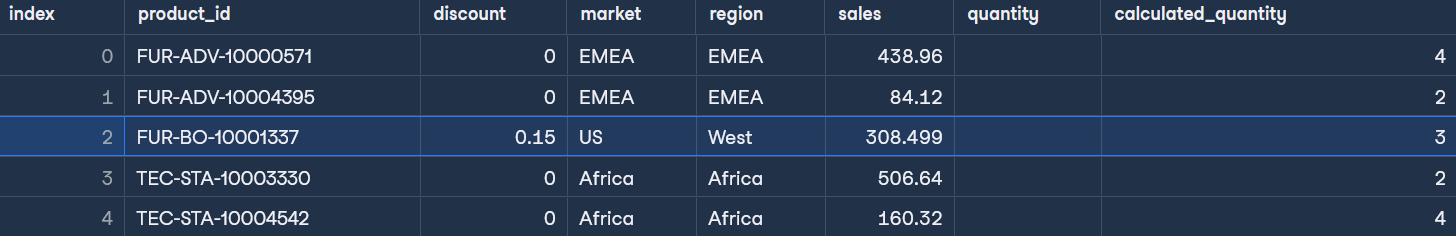